In [2]:
# Import libraries
import numpy as np
%pip install litstudy
import litstudy
import pickle

Note: you may need to restart the kernel to use updated packages.


In [3]:
# load the saved embedding file
docs_ai = []
with open('HEA_Docs_ai.pkl','rb') as f:
#with open('RAC_Docs_ai.pkl','rb') as f:
    docs_ai = pickle.load(f)

docs_nai = []
with open('HEA_Docs_nai.pkl','rb') as f:
#with open('RAC_Docs_nai.pkl','rb') as f:
    docs_nai = pickle.load(f)

print(docs_ai)
print(docs_nai)

<866 documents>
<16758 documents>


Text(0.5, 1.0, 'non-ai paper citation count')

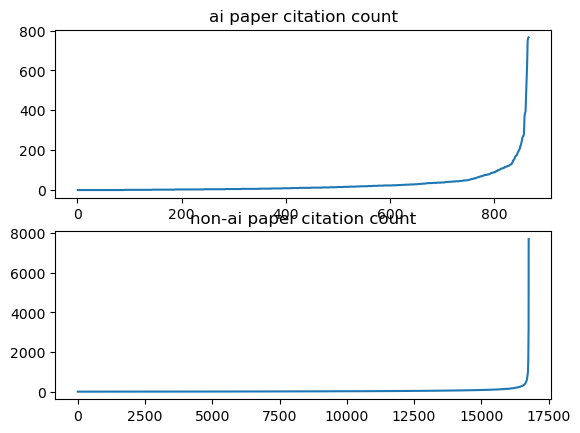

In [4]:
import matplotlib.pyplot as plt
import seaborn as sbs

citation_ai = []
citation_nai = []

for item in docs_ai:
    citation_ai.append(item.citation_count)

for item in docs_nai:
    citation_nai.append(item.citation_count)

x_ai = np.array( range(1,len(docs_ai)+1 ) )
x_nai = np.array( range(1,len(docs_nai)+1) )

y_ai = np.sort(np.array(citation_ai))
y_nai = np.sort(np.array(citation_nai))

#plotting
fig,ax = plt.subplots(2)
ax[0].plot(x_ai,y_ai)
ax[0].set_title("ai paper citation count")
ax[1].plot(x_nai,y_nai)
ax[1].set_title("non-ai paper citation count")

In [30]:
def gini_cal(docs_ai,docs_nai):
    citation_ai = []
    citation_nai = []

    for item in docs_ai:
        citation_ai.append(item.citation_count)

    for item in docs_nai:
        citation_nai.append(item.citation_count)

    x_ai = np.array( range(1,len(docs_ai)+1 ) )
    x_nai = np.array( range(1,len(docs_nai)+1) )

    y_ai = np.sort(np.array(citation_ai))
    y_nai = np.sort(np.array(citation_nai))

    size_ai = len(docs_ai)
    size_nai = len(docs_nai)

    gini_ai = ( 2*np.sum(np.multiply(x_ai,y_ai)) )/(size_ai*np.sum(y_ai)) - (size_ai+1)/size_ai
    gini_nai = ( 2*np.sum(np.multiply(x_nai,y_nai)) )/(size_nai*np.sum(y_nai)) - (size_nai+1)/size_nai

    print(gini_ai,":Gini Coefficient for ai papers")
    print(gini_nai, ":Gini Coefficient for non-ai papers")

gini_cal(docs_ai,docs_nai)


0.7017202583939872 :Gini Coefficient for ai papers
0.7140534350096372 :Gini Coefficient for non-ai papers


In [ ]:
# testing for citation metadata extract --- failed!!!
max_citation_ai = max(y_ai)
print(max_citation_ai, ": number of max citation in ai papers") 
top_ai = docs_ai.filter_docs(lambda d: d. citation_count == max_citation_ai)
print(top_ai[0].citations, ": list of documents that cite this document")
print(top_ai[0].title, ": title ")
print(top_ai[0].publication_year, ": publication year")

max_citation_nai = max(y_nai)
print(max_citation_nai, ": number of max citation in non-ai papers") 
top_nai = docs_nai.filter_docs(lambda d: d. citation_count == max_citation_nai)
print(top_nai[0].citations, ": list of documents that cite this document")
print(top_nai[0].title, ": title ")
print(top_nai[0].publication_year, ": publication year")

766 : number of max citation in ai papers
None : list of documents that cite this document
Fatigue behavior of Al 0.5CoCrCuFeNi high entropy alloys : title 
2012 : publication year
7718 : number of max citation in non-ai papers
None : list of documents that cite this document
A critical review of high entropy alloys and related concepts : title 
2017 : publication year


In [31]:
x = np.array([1,2,3,4,5])
y = np.array([1,1,1,2,15])
gini = ( 2*np.sum(np.multiply(x,y)) )/(5*np.sum(y)) - 6/5
print(gini,":test")

0.5800000000000001 :test
